In [36]:
import numpy as np

import os

import xarray as xr

import glob

import matplotlib.pyplot as plt

import pandas as pd

from matplotlib.colors import BoundaryNorm

import matplotlib.colors as mcolors

import dask.array as da

import pickle

from scipy.stats import t

import matplotlib.ticker as ticker

from pathlib import Path

import cartopy.crs as ccrs

import cartopy.feature as cfeature

import seaborn as sns

### diurnal time tendency (3 hourly)

In [2]:
with open('/home/annierosen16/diurnal_time_tendency.pkl', 'rb') as f:
    
    data = pickle.load(f)

diurnal_time_tendency_dry = list(data['dry'])

diurnal_time_tendency_wet = list(data['wet'])

### diurnal ET (hourly)

In [3]:
with open('/home/annierosen16/et_composites.pkl', 'rb') as f:
    
    diurnal_et = pickle.load(f)
    
    diurnal_et_dry = diurnal_et['dry']
    
    diurnal_et_wet = diurnal_et['wet']

In [4]:
with open('/home/annierosen16/master.pkl', 'rb') as f:
    
    master = pickle.load(f)
    
dry_case = master[master['dryape']==True]

wet_case = master[master['wetape']==True]

hr_to_day = 24

# Stack daily_precip arrays and compute the hourly average

diurnal_precip_dry = np.vstack(dry_case['daily_precip'].values).mean(axis=0) * hr_to_day

diurnal_precip_wet = np.vstack(wet_case['daily_precip'].values).mean(axis=0) * hr_to_day   

### ERA5 reported VIMDF

In [5]:
path = '/home/annierosen16/data/era5sgp/era5_sl_hourly_vimdf_and_tcwv_full_sgp'

files = sorted(glob.glob(f"{path}/*.nc"))

# mbvars = moisture budget variables 

mbvars = xr.open_mfdataset(files, combine="by_coords")

mbvars['valid_time'] = mbvars['valid_time'] - pd.Timedelta(hours=6)

# for vimdf, units are kg/m^2*s = mm/s, so just need to convert from s -> day

# 1/s * 60s/min * 60min/1hr * 24hr/day

sec_to_day = 60 * 60 * 24

mbvars['vimdf_mm_per_day'] = mbvars['vimdf'] * sec_to_day

In [6]:
# Load the pickle file

with open('/home/annierosen16/diurnal_sfc_term.pkl', 'rb') as f:
    
    data = pickle.load(f)

diurnal_sfc_term_dry = data['dry'] * 1000

diurnal_sfc_term_wet = data['wet'] * 1000

### reading in pressure, latitude, longitude

In [7]:
with open('/home/annierosen16/pressure.pkl', 'rb') as f:
    
    pressure = pickle.load(f)
    
with open('/home/annierosen16/sgp_latitudes.pkl', 'rb') as f:
    
    latitude = pickle.load(f)
    
with open('/home/annierosen16/sgp_longitudes.pkl', 'rb') as f:
    
    longitude = pickle.load(f)

### reading in profiles

In [29]:
home_dir = os.path.expanduser("~")

pressure_limit = 925  # hPa

def load_advection_profiles(folder, profile_type):
    
    """
    Load zonal and meridional profiles from pickle files.
    
    Returns two dicts: zonal and meridional
    """
    
    save_folder = os.path.join(home_dir, folder)
    
    files = sorted(glob.glob(os.path.join(save_folder, f"*_{profile_type}_profile.pkl")))
    
    zonal, merid = {}, {}
    
    for f in files:
        # Extract hour label: e.g., '6lst' -> '6'
        time_label = os.path.basename(f).split("_")[0]
        
        hour = time_label.replace("lst", "")
        
        with open(f, "rb") as handle:
            
            profiles = pickle.load(handle)
        
        if hour not in zonal:
            
            zonal[hour] = {}
        
        zonal[hour][f"{time_label}_dry"] = profiles["zonal"]["dry"]
        
        zonal[hour][f"{time_label}_wet"] = profiles["zonal"]["wet"]
        
        if hour not in merid:
            
            merid[hour] = {}
        
        merid[hour][f"{time_label}_dry"] = profiles["meridional"]["dry"]
        
        merid[hour][f"{time_label}_wet"] = profiles["meridional"]["wet"]
    
    return zonal, merid

def load_profiles(folder, profile_type):
    
    """
    Load zonal and meridional profiles from pickle files.
    
    Returns two dicts: zonal and meridional
    """
    
    save_folder = os.path.join(home_dir, folder)
    
    files = sorted(glob.glob(os.path.join(save_folder, f"*_{profile_type}_profile.pkl")))
    
    zonal, merid = {}, {}
    
    for f in files:
        # Extract hour label (e.g., '0lst_convergence_profile.pkl' -> '0lst')
        time_label = os.path.basename(f).split("_")[0]
        
        hour = time_label.replace("lst", "")
        
        with open(f, "rb") as handle:
            
            profiles = pickle.load(handle)
        
        if hour not in zonal:
            
            zonal[hour] = {}
        
        if hour not in merid:
            
            merid[hour] = {}
        
        # Copy keys directly (they already include dry/wet in their names)
        for key, arr in profiles["zonal"].items():
            
            zonal[hour][key] = arr
        
        for key, arr in profiles["meridional"].items():
            
            merid[hour][key] = arr
    
    return zonal, merid


def load_buggy_profiles(pattern):
    
    """
    Load buggy profiles using a glob pattern.
    Returns dict of {hour: data}.
    """
    
    files = glob.glob(os.path.join(home_dir, pattern))
    
    data = {os.path.basename(f).split("lst")[0]: pickle.load(open(f, "rb")) for f in files}
    
    return data


def apply_pressure_mask(profiles_dict, pressure, scale_if_conv=False):
    
    """
    Apply pressure mask to profile dicts (nested dicts of arrays).
    If scale_if_conv=True, multiply values by 1000.
    """
    
    new_dict = {}
    
    mask = pressure <= 925  # boolean mask
    
    for hour, profile_set in profiles_dict.items():
        
        new_dict[hour] = {}
        
        for key, arr in profile_set.items():
            
            masked = arr[mask]  # apply pressure mask
            
            if scale_if_conv:
                
                masked = masked * 1000
            
            new_dict[hour][key] = masked
    
    return new_dict

# --- Convergence single gridpoint Seager ---

zonal_conv, merid_conv = load_profiles("convergence_profiles_single_gridpoint_seager_vectorized", "convergence")

zonal_conv = apply_pressure_mask(zonal_conv, pressure, True)

merid_conv = apply_pressure_mask(merid_conv, pressure, True)

# --- Advection single gridpoint Seager ---

zonal_adv, merid_adv = load_profiles("advection_profiles_single_gridpoint_seager_vectorized", "advection")

zonal_adv = apply_pressure_mask(zonal_adv, pressure, True)

merid_adv = apply_pressure_mask(merid_adv, pressure, True)

# rename inner keys

zonal_conv_gt = {}

for outer_key, inner_dict in zonal_conv.items():
    
    zonal_conv_gt[outer_key] = {}
    
    for k, v in inner_dict.items():
        
        new_key = f"{outer_key}lst_{k}"   # e.g. "0lst_dry"
        
        zonal_conv_gt[outer_key][new_key] = v

merid_conv_gt = {}

for outer_key, inner_dict in merid_conv.items():
    
    merid_conv_gt[outer_key] = {}
    
    for k, v in inner_dict.items():
        
        new_key = f"{outer_key}lst_{k}"   # e.g. "0lst_dry"
        
        merid_conv_gt[outer_key][new_key] = v
        
# rename inner keys

zonal_adv_gt = {}

for outer_key, inner_dict in zonal_adv.items():
    
    zonal_adv_gt[outer_key] = {}
    
    for k, v in inner_dict.items():
        
        new_key = f"{outer_key}lst_{k}"   # e.g. "0lst_dry"
        
        zonal_adv_gt[outer_key][new_key] = v

merid_adv_gt = {}

for outer_key, inner_dict in merid_adv.items():
    
    merid_adv_gt[outer_key] = {}
    
    for k, v in inner_dict.items():
        
        new_key = f"{outer_key}lst_{k}"   # e.g. "0lst_dry"
        
        merid_adv_gt[outer_key][new_key] = v

In [30]:
titles_adv = ["Zonal Advection (Dry)", "Meridional Advection (Dry)",
              "Zonal Advection (Wet)", "Meridional Advection (Wet)"]

titles_conv = ["Zonal Convergence (Dry)", "Meridional Convergence (Dry)",
               "Zonal Convergence (Wet)", "Meridional Convergence (Wet)"]

### plot profiles corrected

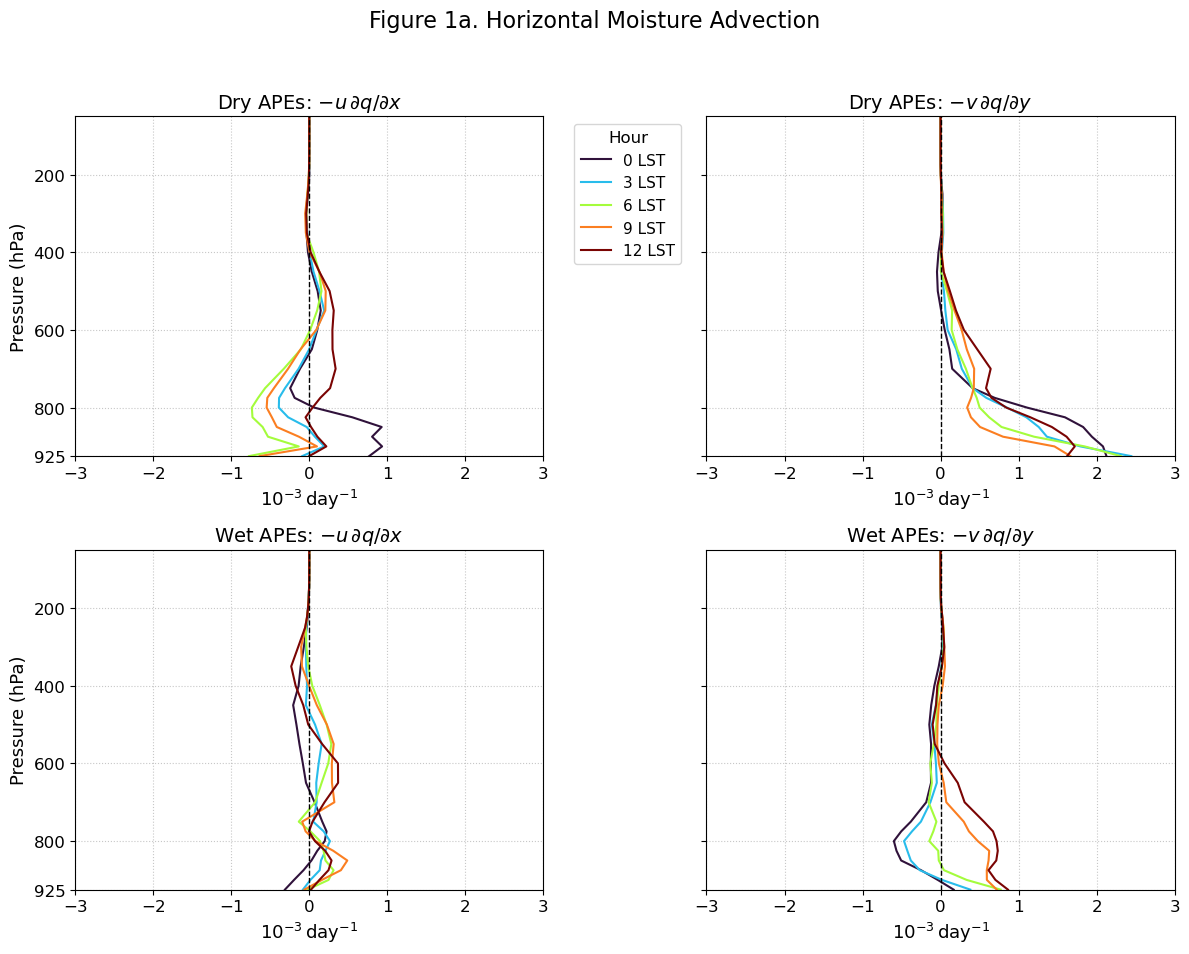

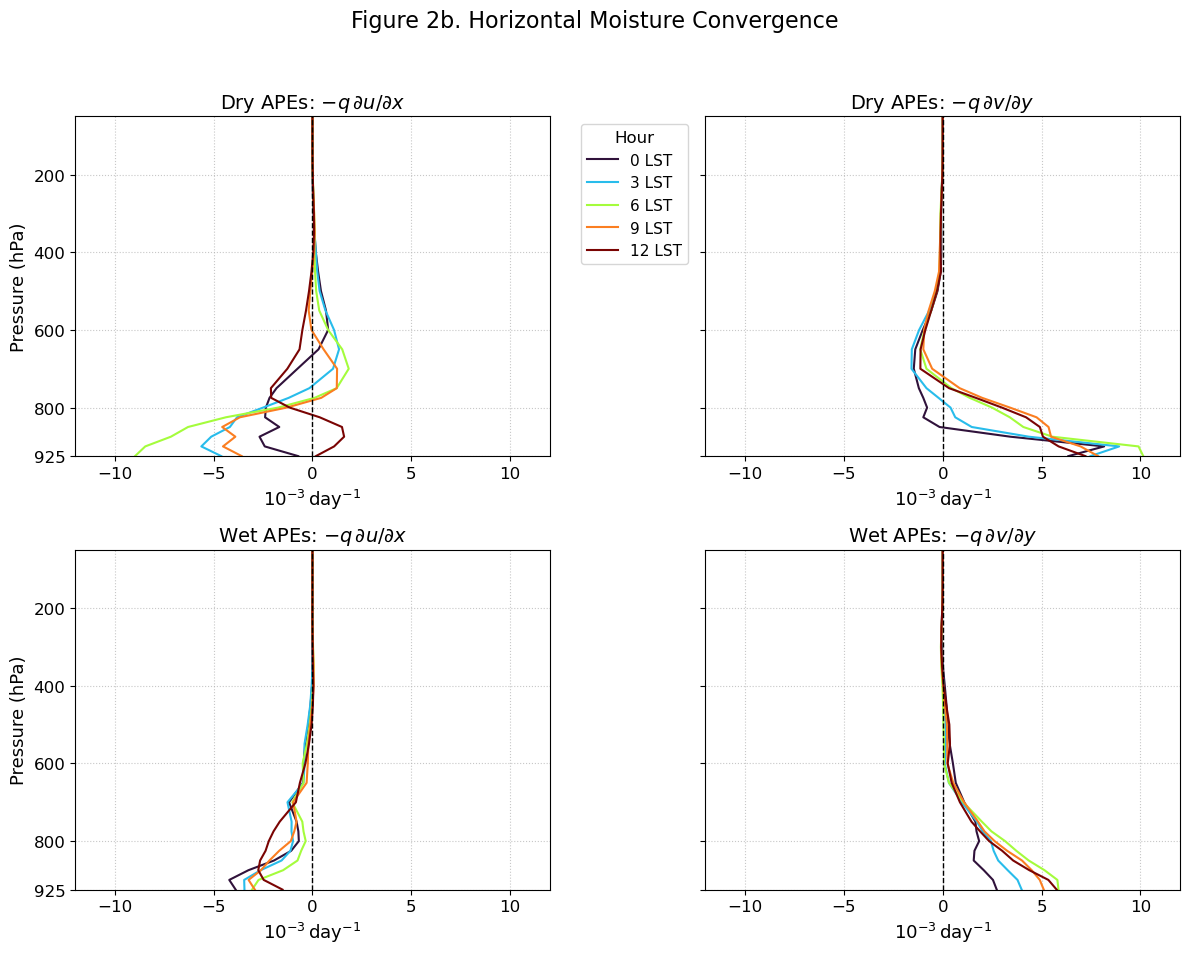

In [33]:
def plot_vertical_profiles(zonal_dict, merid_dict, pressure, hours=[0,3,6,9,12],
                           title_prefix="Horizontal Moisture Advection",
                           xlim=(-3,3), ytick_vals=[925,800,600,400,200],
                           plot_type="advection"):
    """
    Plot vertical profiles for zonal & meridional (dry/wet) quantities.

    plot_type : str, optional
        "advection" or "convergence" - determines subplot titles.
    """

    pressure_masked = pressure[pressure <= 925]
    
    colors = plt.cm.turbo(np.linspace(0, 1, len(hours)))

    fig, axs = plt.subplots(2, 2, figsize=(12, 10), sharey=True)
    axs = axs.flatten()

    # Set titles based on plot type
    if plot_type.lower() == "advection":
        titles = [
            r"Dry APEs: $-u \, \partial q / \partial x$",
            r"Dry APEs: $-v \, \partial q / \partial y$",
            r"Wet APEs: $-u \, \partial q / \partial x$",
            r"Wet APEs: $-v \, \partial q / \partial y$"
        ]
    elif plot_type.lower() == "convergence":
        titles = [
            r"Dry APEs: $-q \, \partial u / \partial x$",
            r"Dry APEs: $-q \, \partial v / \partial y$",
            r"Wet APEs: $-q \, \partial u / \partial x$",
            r"Wet APEs: $-q \, \partial v / \partial y$"
        ]
    else:
        raise ValueError("plot_type must be 'advection' or 'convergence'")

    for i, hour in enumerate(hours):
        hour_str = str(hour)
        color = colors[i]

        # Extract profiles
        zonal_dry = zonal_dict[hour_str][f"{hour_str}lst_dry"]
        merid_dry = merid_dict[hour_str][f"{hour_str}lst_dry"]
        zonal_wet = zonal_dict[hour_str][f"{hour_str}lst_wet"]
        merid_wet = merid_dict[hour_str][f"{hour_str}lst_wet"]

        # Plot profiles
        axs[0].plot(zonal_dry, pressure_masked, color=color, label=f"{hour} LST")
        axs[1].plot(merid_dry, pressure_masked, color=color)
        axs[2].plot(zonal_wet, pressure_masked, color=color)
        axs[3].plot(merid_wet, pressure_masked, color=color)

    # Style subplots
    for ax, title in zip(axs, titles):
        ax.set_title(title, fontsize=14)
        ax.set_xlim(xlim)
        ax.set_ylim(np.max(pressure_masked), np.min(pressure_masked))  # Invert y-axis
        ax.set_yticks(ytick_vals)
        ax.set_yticklabels([str(int(p)) for p in ytick_vals], fontsize=12)
        ax.set_xlabel(r"$10^{-3} \, \mathrm{day}^{-1}$", fontsize=13)
        ax.grid(True, linestyle=':', alpha=0.7)
        ax.axvline(0, color='black', linestyle='--', linewidth=1)
        ax.tick_params(axis='x', labelsize=12)
        ax.tick_params(axis='y', labelsize=12)

    # Y-labels for left column
    axs[0].set_ylabel("Pressure (hPa)", fontsize=13)
    axs[2].set_ylabel("Pressure (hPa)", fontsize=13)

    # Legend
    axs[0].legend(title="Hour", fontsize=11, title_fontsize=12,
                  bbox_to_anchor=(1.05, 1), loc='upper left')

    plt.suptitle(title_prefix, fontsize=16)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()


# --- Example calls ---
# Horizontal Moisture Advection
plot_vertical_profiles(zonal_adv_gt, merid_adv_gt, pressure, title_prefix="Figure 1a. Horizontal Moisture Advection", plot_type="advection")

# Horizontal Moisture Convergence (q du/dx, q dv/dy)
plot_vertical_profiles(zonal_conv_gt, merid_conv_gt, pressure, 
                       title_prefix="Figure 2b. Horizontal Moisture Convergence",
                       xlim=(-12, 12),
                       plot_type="convergence")


### vertically integrate profiles

In [11]:
## vertically integrate horizontal convergence & advection

def vertically_integrated_profile_in_pressure(profile, levels):
    
    g = 9.81  # Gravitational acceleration in m/s^2
    
    rho_water = 1000  # Density of water in kg/m^3
    
    m_to_mm = 1000
                    
    dp = np.diff(levels)
            
    integrated_value = (np.sum(0.5 * (profile[:-1] + profile[1:]) * dp) / (g * rho_water)) * m_to_mm

    return integrated_value

def integrate_profiles(data, pressure, unit_adjustment=1000, apply_unit_adjustment=True):
    
    pressure_for_integration = pressure * 100
        
    integrated_profiles = {}

    for time, label_dict in data.items():
        
        integrated_profiles[time] = {}
        
        for label, profile in label_dict.items():
            
            if apply_unit_adjustment:
                
                profile = profile / unit_adjustment
            
            integrated_profiles[time][label] = vertically_integrated_profile_in_pressure(profile, pressure_for_integration)
    
    return integrated_profiles

## units = mm/day

pressure_masked = pressure[pressure <= 925]

# without bug 

int_zonal_adv = integrate_profiles(zonal_adv_gt, pressure_masked)

int_merid_adv = integrate_profiles(merid_adv_gt, pressure_masked)

int_zonal_conv = integrate_profiles(zonal_conv_gt, pressure_masked)

int_merid_conv = integrate_profiles(merid_conv_gt, pressure_masked)

### extract times from integrated values

In [12]:
def extract_diurnal_cycles(profiles_dict, label_prefix='lst'):
    
    """
    Extract diurnal cycles from a nested dict of integrated profiles.
    
    Returns:
        hours: list of hour integers
        dry_values: list of dry profiles
        wet_values: list of wet profiles
    """
    sorted_hours = sorted(profiles_dict.keys(), key=lambda x: int(x))
    
    dry_values = [profiles_dict[hour][f"{hour}{label_prefix}_dry"] for hour in sorted_hours]
    
    wet_values = [profiles_dict[hour][f"{hour}{label_prefix}_wet"] for hour in sorted_hours]
    
    hours = [int(hour) for hour in sorted_hours]
    
    return hours, dry_values, wet_values


# --- Extract diurnal cycles for advection ---

hours_zonal_adv, zonal_dry_adv, zonal_wet_adv = extract_diurnal_cycles(int_zonal_adv)

_, merid_dry_adv, merid_wet_adv = extract_diurnal_cycles(int_merid_adv)

hours_zonal_conv, zonal_dry_conv, zonal_wet_conv = extract_diurnal_cycles(int_zonal_conv)

_, merid_dry_conv, merid_wet_conv = extract_diurnal_cycles(int_merid_conv)

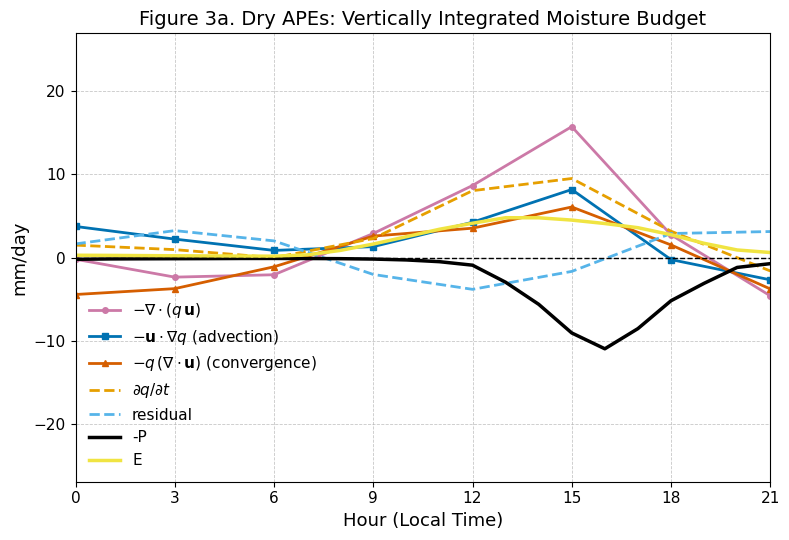

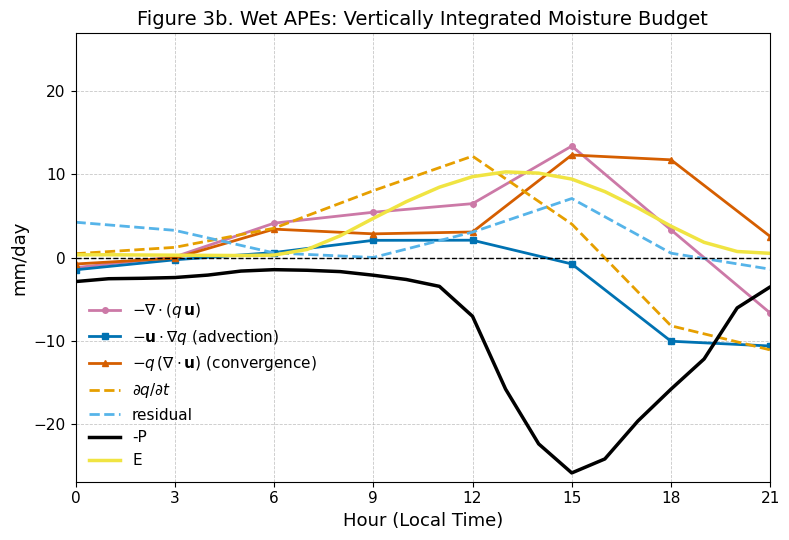

In [13]:
hours_24 = range(0,24)

diurnal_mfc_dry = np.array(zonal_dry_adv) + np.array(merid_dry_adv) + np.array(zonal_dry_conv) + np.array(merid_dry_conv) + np.array(diurnal_sfc_term_dry)

diurnal_mfc_wet = np.array(zonal_wet_adv) + np.array(merid_wet_adv) + np.array(zonal_wet_conv) + np.array(merid_wet_conv) + np.array(diurnal_sfc_term_wet)

diurnal_adv_dry = np.array(zonal_dry_adv) + np.array(merid_dry_adv)

diurnal_adv_wet = np.array(zonal_wet_adv) + np.array(merid_wet_adv)

diurnal_conv_wet = np.array(zonal_wet_conv) + np.array(merid_wet_conv)

diurnal_conv_dry = np.array(zonal_dry_conv) + np.array(merid_dry_conv)

def plot_diurnal_moisture_budget(hours_24, precip, et, mfc, adv, conv, time_tend, title):
    
    precip = np.array(precip) * -1 # multiplication by -1 to be consistent with dq/dt = MFC - P + E form of budget
    
    et = np.array(et)
    
    adv = np.array(adv)
    
    conv = np.array(conv)
    
    mfc_total = np.array(mfc)
    
    time_tend = np.array(time_tend)
    
    # Only take every 3rd element for 3-hourly fields
    
    precip_3hr = precip[::3] * -1 # multiply by -1 to reverse back to positive values for residual calculation
    
    et_3hr = et[::3]
    
    hours_3hr = hours_24[::3]
    
    residual = (precip_3hr - et_3hr) + time_tend - mfc
    
#     print(np.mean(abs(residual)))
        
    plt.figure(figsize=(8, 5.5))

    # Plot 3-hourly budget terms

    plt.plot(hours_3hr, mfc_total, label=r'$-\nabla \cdot (q \, \mathbf{u})$', 
         
             color='#CC79A7', linewidth=2, marker='o', markersize=4)  # Reddish purple
    
    plt.plot(hours_3hr, adv, 
         label=r'$-\mathbf{u} \cdot \nabla q$ (advection)', 
         color='#0072B2', linewidth=2, marker='s', markersize=4)  # Blue

    
    plt.plot(hours_3hr, conv, 
         label=r'$-q \, (\nabla \cdot \mathbf{u})$ (convergence)', 
         color='#D55E00', linewidth=2, marker='^', markersize=4)  # Reddish orange


    plt.plot(hours_3hr, time_tend, label=r'$\partial q/\partial t$', 
         
             color='#E69F00', linestyle='--', linewidth=2)  # Orange

    plt.plot(hours_3hr, residual, label='residual', 
         
             color='#56B4E9', linestyle='--', linewidth=2)  # Sky blue

    plt.plot(hours_24, precip, label='-P', 
         
             color='#000000', linewidth=2.5)        # Black

    plt.plot(hours_24, et, label='E', 
         
             color='#F0E442', linewidth=2.5)        # Yellow

    # Axes and labels
    
    plt.xlabel('Hour (Local Time)', fontsize=13)
    
    plt.ylabel('mm/day', fontsize=13)
    
    plt.title(title, fontsize=14)
    
    plt.grid(True, which='both', linestyle='--', linewidth=0.6, alpha=0.7)
    
    plt.xticks(range(0, 24, 3), fontsize=11)
    
    plt.yticks(fontsize=11)
    
    plt.xlim(0, 21)
    
    plt.axhline(0, color='black', linestyle='--', linewidth=1)
    
    plt.legend(loc='lower left', fontsize=11, frameon=False)
    
    plt.tight_layout()
    
    plt.ylim(-27, 27)
    
    plt.show()


# Plot for DRY APEs

plot_diurnal_moisture_budget(
    
    hours_24,
    
    diurnal_precip_dry,
    
    diurnal_et_dry,
    
    diurnal_mfc_dry, 
    
    diurnal_adv_dry, 
    
    diurnal_conv_dry, 
    
    diurnal_time_tendency_dry, 
    
    title='Figure 3a. Dry APEs: Vertically Integrated Moisture Budget'
)

# Plot for WET APEs

plot_diurnal_moisture_budget(
    
    hours_24,
    
    diurnal_precip_wet,
    
    diurnal_et_wet,
    
    diurnal_mfc_wet, 
    
    diurnal_adv_wet, 
    
    diurnal_conv_wet,
    
    diurnal_time_tendency_wet,
    
    title='Figure 3b. Wet APEs: Vertically Integrated Moisture Budget')

In [14]:
self_calculated_mfc = (diurnal_mfc_dry, diurnal_mfc_wet)

with open('self_calculated_mfc.pkl', 'wb') as f:
    
    pickle.dump(self_calculated_mfc, f)